Write a Python function numerical gradient(f, x, epsilon=1e-7) that takes a function f, a
NumPy vector x, and computes the numerical gradient using the central difference formula. It
should iterate through each dimension of x, perturb it in both the positive and negative directions
using the corresponding unit vector ej , and calculate the approximate partial derivative for that
dimension.

In [17]:
import numpy as np
def numerical_gradient(f, x, epsilon = 1e-7, *args):
    """
    Approximates the gradient of a function using the finite difference formula.
    """
    A, y = args
    gradient = np.zeros(x.shape)
    for i in range(x.shape[0]):
        x_plus = x.copy()
        x_minus = x.copy()

        x_plus[i] += epsilon
        x_minus[i] -= epsilon
        gradient[i] = (
            f(A, y, x_plus) - f(A, y, x_minus)
        ) / (2 * epsilon)
    return gradient


In [24]:
def least_squares_cost(A, y, w):
    n, p = A.shape
    y_hat = A @ w

    squared_differences = np.square(y - y_hat)
    return (1/n) * np.sum(squared_differences)

def least_squares_analytical_gradient(A, y, w):
    n, p = A.shape
    y_hat = A @ w
    residuals = y - y_hat

    individual_gradients = A.T @ residuals
    return (-2 / n) * individual_gradients

In [19]:
def gradient_checker(f, analytical_grad_func, x, epsilon, *args):
    gradient_f_numerical = numerical_gradient(f, x, epsilon, *args)
    gradient_f_analytical = analytical_grad_func(*args, x)
    difference = gradient_f_analytical - gradient_f_numerical
    
    l2_gradient_f_numerical_squared = np.linalg.norm(gradient_f_numerical) ** 2
    l2_gradient_f_analytical_squared = np.linalg.norm(gradient_f_analytical) ** 2
    l2_gradient_difference_squared = np.linalg.norm(difference) ** 2
    return l2_gradient_difference_squared / (l2_gradient_f_analytical_squared + l2_gradient_f_numerical_squared)

In [25]:
n = 50
p = 10
A_rand = np.random.rand(n, p)
w_rand = np.random.rand(p, )
y_rand = np.random.rand(n)
error = gradient_checker(least_squares_cost, least_squares_analytical_gradient, w_rand, 1e-5, A_rand, y_rand)
print(error)

9.408234522305098e-23


Plot saved as 'num_grad_acc.png


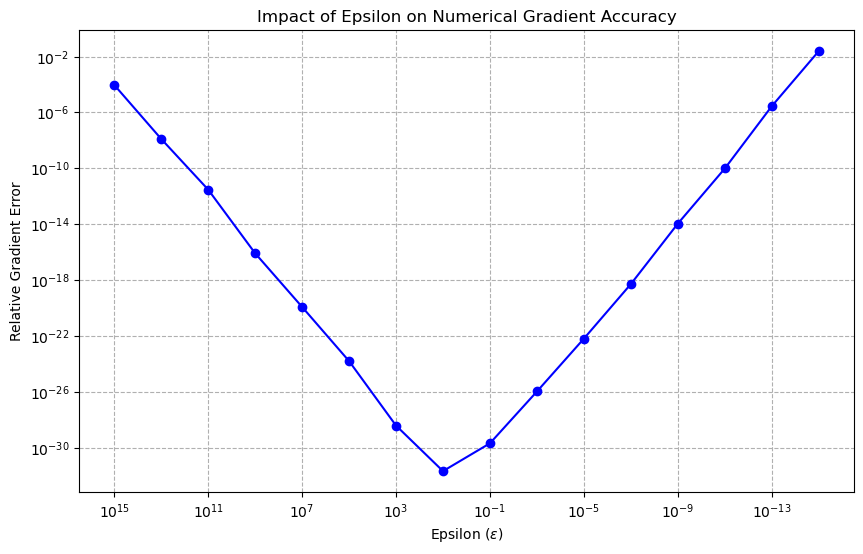

In [34]:
import matplotlib.pyplot as plt

epsilons = np.logspace(15, -15, 16)
errors = []
n = 50
p = 10
A_rand = np.random.rand(n, p)
w_rand = np.random.rand(p, )
y_rand = np.random.rand(n)
for epsilon in epsilons:
    errors.append(gradient_checker(least_squares_cost, least_squares_analytical_gradient, w_rand, epsilon, A_rand, y_rand))

plt.figure(figsize = (10, 6))
plt.plot(epsilons, errors, 'bo-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Epsilon ($\\epsilon$)")
plt.ylabel("Relative Gradient Error")
plt.title("Impact of Epsilon on Numerical Gradient Accuracy")
plt.gca().invert_xaxis()
plt.grid(True, which = "both", ls = "--")
plt.savefig('num_grad_acc.png', bbox_inches = 'tight')
print("Plot saved as 'num_grad_acc.png")
plt.show()